# HATR cross-framework — Performance computazionale

Confronto del costo computazionale di HATR in River (Python) e CapyMOA (JVM via JNI): tempo di training, inferenza, throughput e crescita della dimensione modello.

## Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jpype
import jpype.config
jpype.config.destroy_jvm = False

HATR_JAR = os.path.normpath(os.path.join(os.getcwd(), '..', 'implementation',
    'hatr-moa', 'target',
    'hoeffding-adaptive-tree-regressor-moa-1.0-SNAPSHOT.jar'))
assert os.path.exists(HATR_JAR), f"JAR non trovato: {HATR_JAR}\ncompilare: cd implementation/hatr-moa && mvn -o package -DskipTests"

if jpype.isJVMStarted():
    print('JVM già avviata — Kernel -> Restart & Run All')
else:
    SIZEOF_JAR = os.path.expanduser(
        "~/.m2/repository/com/github/fracpete/sizeofag/1.1.0/sizeofag-1.1.0.jar")
    if os.path.exists(SIZEOF_JAR):
        os.environ["CAPYMOA_JVM_ARGS"] = (
            f"-Xmx8g -Xss10M -javaagent:{SIZEOF_JAR} "
            "--add-opens=java.base/java.util=ALL-UNNAMED "
            "--add-opens=java.base/java.lang=ALL-UNNAMED "
            "--add-opens=java.base/java.lang.reflect=ALL-UNNAMED "
            "-XX:ErrorFile=/dev/null"
        )
    else:
        os.environ["CAPYMOA_JVM_ARGS"] = "-Xmx8g -Xss10M -XX:ErrorFile=/dev/null"
    jpype.addClassPath(HATR_JAR)

from capymoa.datasets import Bike, Fried
from capymoa.stream.generator import HyperPlaneRegression
import psutil
from pympler import asizeof

import utils   # importato dopo JVM: gestisce sys.path, capymoa, river, hatr_capymoa

print("Setup OK — JVM avviata, HATR caricato, River e CapyMOA importati")

Setup OK — JVM avviata, HATR caricato, River e CapyMOA importati


## Dataset

In [2]:
MAX_INSTANCES = 17000
SYN_N, SYN_DRIFT = 17000, 5000

import urllib.request, gzip, shutil

DATA_DIR = os.path.normpath(os.path.join(os.getcwd(), 'data'))
os.makedirs(DATA_DIR, exist_ok=True)

_ELEC_PATH = os.path.join(DATA_DIR, 'electricity.arff')
_ELEC_URL  = 'https://www.dropbox.com/scl/fi/p7btran9xdas20neva917/electricity.arff.gz?rlkey=xt8hc6542b8wr01eitcw7mwpz&st=paqojdax&dl=1'
if not os.path.exists(_ELEC_PATH):
    print('Downloading electricity.arff...')
    _gz = _ELEC_PATH + '.gz'
    urllib.request.urlretrieve(_ELEC_URL, _gz)
    with gzip.open(_gz, 'rb') as _f_in, open(_ELEC_PATH, 'wb') as _f_out:
        shutil.copyfileobj(_f_in, _f_out)
    os.remove(_gz)
    print('Done.')

datasets = {}
datasets["Synthetic"] = utils.make_synthetic(n=SYN_N, drift_at=SYN_DRIFT)
datasets["Bike"] = utils.materialize_stream(Bike(), MAX_INSTANCES)
datasets["Fried"] = utils.materialize_stream(Fried(), MAX_INSTANCES)
datasets["Hyper"] = utils.materialize_stream(
    HyperPlaneRegression(instance_random_seed=1, number_of_attributes=10,
                         number_of_drifting_attributes=2, magnitude_of_change=0.001,
                         noise_percentage=5),
    MAX_INSTANCES)
datasets["HyperFast"] = utils.materialize_stream(
    HyperPlaneRegression(instance_random_seed=1, number_of_attributes=10,
                         number_of_drifting_attributes=5, magnitude_of_change=0.1,
                         noise_percentage=10),
    MAX_INSTANCES)
datasets["FriedDrift"] = utils.make_fried_drift(
    n=MAX_INSTANCES, drift_at=MAX_INSTANCES // 2)
datasets["RBFReg"] = utils.make_rbf_regression(
    n=MAX_INSTANCES, drift_at=MAX_INSTANCES // 2)
datasets["ElectricityDemand"] = utils.load_electricity_demand(
    os.path.join(DATA_DIR, 'electricity.arff'), max_instances=MAX_INSTANCES)

for name, (X, y, schema) in datasets.items():
    print(f"{name:<20} n={len(X):>6}  feat={X.shape[1]:>2}  y\u2208[{y.min():.2f}, {y.max():.2f}]")

Done.
Synthetic            n= 17000  feat= 5  y∈[-14.29, 15.55]
Bike                 n= 17000  feat=12  y∈[1.00, 977.00]
Fried                n= 17000  feat=10  y∈[-1.23, 30.05]
Hyper                n= 17000  feat=10  y∈[93.98, 677.42]
HyperFast            n= 17000  feat=10  y∈[-4117.78, 11925.45]
FriedDrift           n= 17000  feat=10  y∈[-0.69, 30.15]
RBFReg               n= 17000  feat=10  y∈[-13.18, 16.44]
ElectricityDemand    n= 17000  feat= 7  y∈[0.00, 0.94]


In [15]:
import pandas as pd
import re

def _feat_names(schema, n):
    attrs = re.findall(
        r'@attribute\s+(\S+)\s+({[^}]+}|\S+)',
        str(schema), re.IGNORECASE)
    if len(attrs) >= n:
        return [f'{name} ({"nom" if typ.startswith("{") else "num"})'
                for name, typ in attrs[:n]]
    return [f'x{i}' for i in range(n)]

for name, (X, y, schema) in datasets.items():
    print(f"\n{'='*60}")
    print(f"  {name}  —  {len(X)} istanze, {X.shape[1]} feature")
    print(f"  schema: {schema}")
    cols = _feat_names(schema, X.shape[1])
    df = pd.DataFrame(X[:5], columns=cols)
    df['[y]'] = y[:5]
    display(df.round(4))



  Synthetic  —  17000 istanze, 5 feature
  schema: @relation synthetic_drift

@attribute x0 numeric
@attribute x1 numeric
@attribute x2 numeric
@attribute x3 numeric
@attribute x4 numeric
@attribute y numeric

@data


,x0,x1,x2,x3,x4,[y]
0,0.4967,-0.1383,0.6477,1.5230,-0.2342,0.0886
1,-0.2341,1.5792,0.7674,-0.4695,0.5426,3.5357
2,-0.4634,-0.4657,0.2420,-1.9133,-1.7249,-2.7065
3,-0.5623,-1.0128,0.3142,-0.9080,-1.4123,-4.4060
4,1.4656,-0.2258,0.0675,-1.4247,-0.5444,2.1874



  Bike  —  17000 istanze, 12 feature
  schema: @relation bike-share-hour_transform_1

@attribute season numeric
@attribute yr numeric
@attribute mth numeric
@attribute hr numeric
@attribute holiday numeric
@attribute weekday numeric
@attribute workingday numeric
@attribute weathersit numeric
@attribute temp numeric
@attribute atemp numeric
@attribute hum numeric
@attribute windspeed numeric
@attribute cnt numeric

@data


,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,[y]
0,1.0000,0.0000,1.0000,0.0000,0.0000,6.0000,0.0000,1.0000,0.2400,0.2879,0.8100,0.0000,16.0000
1,1.0000,0.0000,1.0000,1.0000,0.0000,6.0000,0.0000,1.0000,0.2200,0.2727,0.8000,0.0000,40.0000
2,1.0000,0.0000,1.0000,2.0000,0.0000,6.0000,0.0000,1.0000,0.2200,0.2727,0.8000,0.0000,32.0000
3,1.0000,0.0000,1.0000,3.0000,0.0000,6.0000,0.0000,1.0000,0.2400,0.2879,0.7500,0.0000,13.0000
4,1.0000,0.0000,1.0000,4.0000,0.0000,6.0000,0.0000,1.0000,0.2400,0.2879,0.7500,0.0000,1.0000



  Fried  —  17000 istanze, 10 feature
  schema: @relation data_res_fried.

@attribute attr_0 numeric
@attribute attr_1 numeric
@attribute attr_2 numeric
@attribute attr_3 numeric
@attribute attr_4 numeric
@attribute attr_5 numeric
@attribute attr_6 numeric
@attribute attr_7 numeric
@attribute attr_8 numeric
@attribute attr_9 numeric
@attribute target numeric

@data


...

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,[y]
0,0.3745,0.9507,0.7320,0.5987,0.1560,0.1560,0.0581,0.8662,0.6011,0.7081,16.7603
1,0.0206,0.9699,0.8324,0.2123,0.1818,0.1834,0.3042,0.5248,0.4319,0.2912,6.8027
2,0.6119,0.1395,0.2921,0.3664,0.4561,0.7852,0.1997,0.5142,0.5924,0.0465,11.1459
3,0.6075,0.1705,0.0651,0.9489,0.9656,0.8084,0.3046,0.0977,0.6842,0.4402,21.5100
4,0.1220,0.4952,0.0344,0.9093,0.2588,0.6625,0.3117,0.5201,0.5467,0.1849,17.1465



  RBFReg  —  17000 istanze, 10 feature
  schema: @relation rbf_regression

@attribute x0 numeric
@attribute x1 numeric
@attribute x2 numeric
@attribute x3 numeric
@attribute x4 numeric
@attribute x5 numeric
@attribute x6 numeric
@attribute x7 numeric
@attribute x8 numeric
@attribute x9 numeric
@attribute y numeric

@data


,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,[y]
0,0.2505,0.3464,-0.6800,0.2323,0.2931,-0.7144,1.8658,0.4738,-1.1913,0.6566,2.4634
1,-0.9747,0.7871,1.1586,-0.8207,0.9634,0.4128,0.8221,1.8968,-0.2454,-0.7537,3.2183
2,-0.8895,-0.8158,-0.0771,0.3412,0.2767,0.8272,0.0130,1.4535,-0.2647,2.7202,1.4445
3,0.6257,-0.8572,-1.0709,0.4825,-0.2235,0.7140,0.4732,-0.0728,-0.8468,-1.5148,-0.1328
4,-0.4465,0.8564,0.2141,-1.2457,0.1732,0.3853,-0.8839,0.1537,0.0582,-1.1430,3.1112



  ElectricityDemand  —  17000 istanze, 7 feature
  schema: @relation electricity_demand

@attribute date numeric
@attribute day numeric
@attribute period numeric
@attribute nswprice numeric
@attribute vicprice numeric
@attribute vicdemand numeric
@attribute transfer numeric
@attribute nswdemand numeric

@data


,x0,x1,x2,x3,x4,x5,x6,[y]
0,0.0000,2.0000,0.0000,0.0564,0.0035,0.4229,0.4149,0.4392
1,0.0000,2.0000,0.0213,0.0517,0.0035,0.4229,0.4149,0.4151
2,0.0000,2.0000,0.0426,0.0515,0.0035,0.4229,0.4149,0.3850
3,0.0000,2.0000,0.0638,0.0455,0.0035,0.4229,0.4149,0.3146
4,0.0000,2.0000,0.0851,0.0425,0.0035,0.4229,0.4149,0.2511


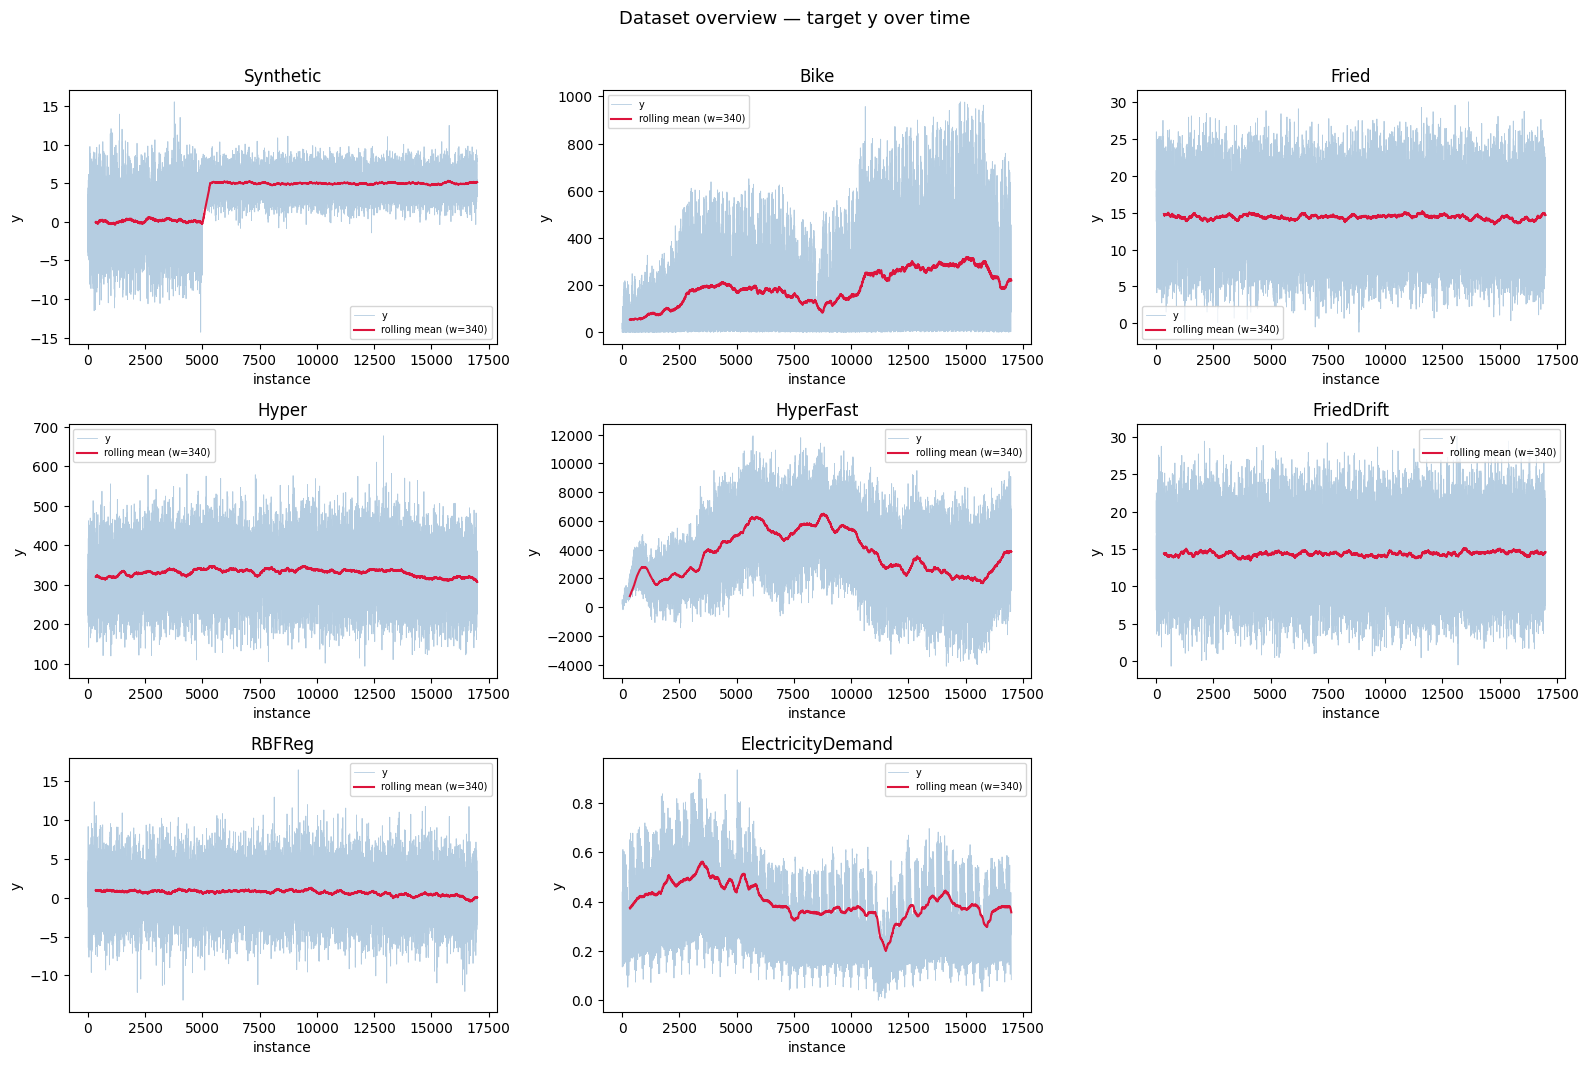

In [3]:
import matplotlib.pyplot as plt
import numpy as np

drift_points = {
    'Synthetic':  SYN_DRIFT,
    'FriedDrift': MAX_INSTANCES // 2,
    'RBFReg':     MAX_INSTANCES // 2,
}

ncols = 3
nrows = -(-len(datasets) // ncols)  # ceil division
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.5 * nrows))
axes = axes.flatten()

for ax, (name, (X, y, _)) in zip(axes, datasets.items()):
    ax.plot(y, color='steelblue', alpha=0.4, linewidth=0.6, label='y')
    window = max(1, len(y) // 50)
    rolling = np.convolve(y, np.ones(window) / window, mode='valid')
    ax.plot(range(window - 1, len(y)), rolling, color='crimson',
            linewidth=1.5, label=f'rolling mean (w={window})')
    if name in drift_points:
        ax.axvline(drift_points[name], color='orange', linestyle='--',
                   linewidth=1.5, label=f'drift @ {drift_points[name]}')
    ax.set_title(name)
    ax.set_xlabel('instance')
    ax.set_ylabel('y')
    ax.legend(fontsize=7)

for ax in axes[len(datasets):]:
    ax.set_visible(False)

fig.suptitle('Dataset overview — target y over time', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## Parametri

In [10]:
BASE = dict(grace_period=50, delta=1e-7, tau=0.05, model_selector_decay=0.95,
            drift_window_threshold=500, switch_significance=0.05,
            min_samples_split=5, adwin_delta=0.0001, learning_ratio=0.01, seed=0)

CONFIGS = {
    "deterministic (mean, no-bootstrap)": dict(leaf_prediction="mean",     bootstrap_sampling=False),
    "default (adaptive, bootstrap)":      dict(leaf_prediction="adaptive", bootstrap_sampling=True),
}

SCALE = True

## Esecuzione

In [11]:
SAMPLE_EVERY = 500
PERF_CONFIG  = "default (adaptive, bootstrap)"
cfg = CONFIGS[PERF_CONFIG]

# warmup JVM: evita che il JIT di HotSpot penalizzi il primo dataset (Bike)
_w_X, _w_y, _w_schema = next(iter(datasets.values()))
utils.prequential_eval(_w_X[:10000], _w_y[:10000], 'capy', cfg, BASE, schema=_w_schema, scale=SCALE)

rows = []
for ds_name, (X, y, schema) in datasets.items():
    n = len(X)
    _, r_model, rt_p, rt_t, _ = utils.prequential_eval(X, y, 'river', cfg, BASE, time_algo=True)
    _, c_learner, ct_p, ct_t, _ = utils.prequential_eval(X, y, 'capy', cfg, BASE, schema=schema, time_algo=True)
    r_mb = utils.river_model_mb(r_model)
    c_mb = utils.capy_model_mb(c_learner)
    rows.append(dict(dataset=ds_name, framework="River", n=n,
                     train_s=rt_t, predict_s=rt_p, total_s=rt_t + rt_p,
                     inst_per_s=n / (rt_t + rt_p), model_MB=r_mb))
    rows.append(dict(dataset=ds_name, framework="CapyMOA", n=n,
                     train_s=ct_t, predict_s=ct_p, total_s=ct_t + ct_p,
                     inst_per_s=n / (ct_t + ct_p), model_MB=c_mb))
    print(f"  {ds_name:<10} River {rt_t+rt_p:6.2f}s {r_mb:.3f} MB  |  CapyMOA {ct_t+ct_p:6.2f}s {c_mb:.4f} MB")

perf = pd.DataFrame(rows)
speedup = (perf[perf.framework == "CapyMOA"].set_index("dataset")["inst_per_s"] /
           perf[perf.framework == "River"].set_index("dataset")["inst_per_s"])
perf["speedup_vs_river"] = perf["dataset"].map(speedup)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
perf

  Synthetic  River   1.96s 3.485 MB  |  CapyMOA   0.53s 0.4493 MB
  Bike       River   1.81s 1.457 MB  |  CapyMOA   0.45s 0.3459 MB
  Fried      River   3.72s 3.866 MB  |  CapyMOA   0.58s 0.2726 MB
  Hyper      River   3.57s 0.873 MB  |  CapyMOA   0.62s 0.1711 MB
  HyperFast  River   3.66s 0.205 MB  |  CapyMOA   0.63s 0.1435 MB
  FriedDrift River   3.17s 5.810 MB  |  CapyMOA   0.53s 0.8402 MB
  RBFReg     River   3.62s 1.586 MB  |  CapyMOA   0.53s 0.6841 MB
  ElectricityDemand River   1.23s 0.829 MB  |  CapyMOA   0.32s 0.0564 MB


,dataset,framework,n,train_s,predict_s,total_s,inst_per_s,model_MB,speedup_vs_river
0,Synthetic,River,17000,1.8496,0.1108,1.9604,8671.7825,3.4848,3.6892
1,Synthetic,CapyMOA,17000,0.4418,0.0896,0.5314,31992.0512,0.4493,3.6892
2,Bike,River,17000,1.7275,0.0795,1.8070,9407.9476,1.4575,4.0492
3,Bike,CapyMOA,17000,0.3792,0.0670,0.4463,38094.8856,0.3459,4.0492
4,Fried,River,17000,3.6135,0.1082,3.7217,4567.8063,3.8660,6.4695
5,Fried,CapyMOA,17000,0.4454,0.1299,0.5753,29551.2850,0.2726,6.4695
6,Hyper,River,17000,3.4731,0.0923,3.5654,4768.0013,0.8731,5.7202
7,Hyper,CapyMOA,17000,0.5568,0.0665,0.6233,27274.1483,0.1711,5.7202
8,HyperFast,River,17000,3.5924,0.0669,3.6593,4645.6436,0.2055,5.8536
9,HyperFast,CapyMOA,17000,0.4980,0.1272,0.6251,27193.9630,0.1435,5.8536


## Grafici

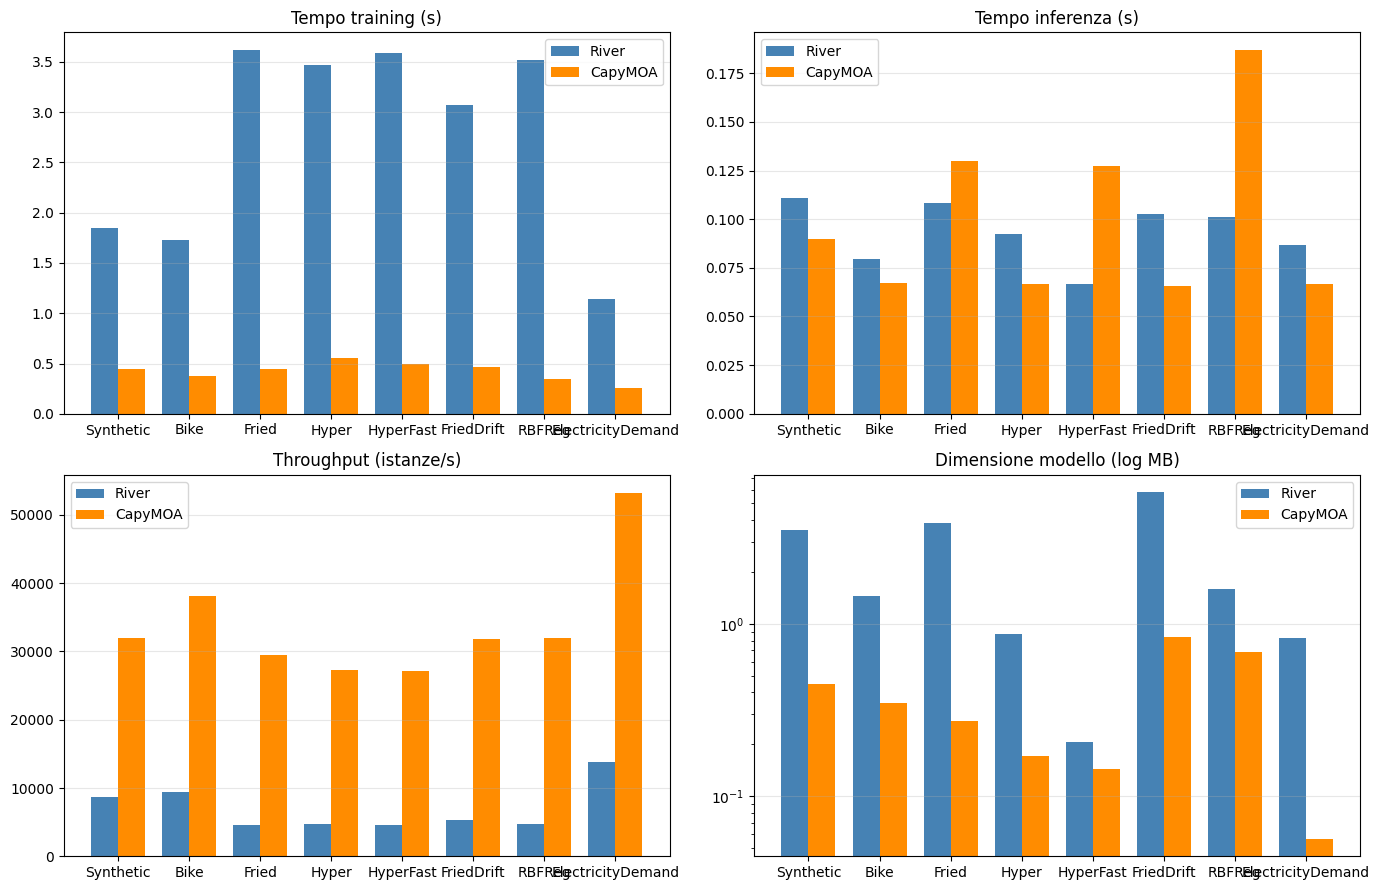

          dataset framework  train_s  predict_s  inst_per_s  model_MB  speedup_vs_river
        Synthetic     River   1.8496     0.1108   8671.7825    3.4848            3.6892
        Synthetic   CapyMOA   0.4418     0.0896  31992.0512    0.4493            3.6892
             Bike     River   1.7275     0.0795   9407.9476    1.4575            4.0492
             Bike   CapyMOA   0.3792     0.0670  38094.8856    0.3459            4.0492
            Fried     River   3.6135     0.1082   4567.8063    3.8660            6.4695
            Fried   CapyMOA   0.4454     0.1299  29551.2850    0.2726            6.4695
            Hyper     River   3.4731     0.0923   4768.0013    0.8731            5.7202
            Hyper   CapyMOA   0.5568     0.0665  27274.1483    0.1711            5.7202
        HyperFast     River   3.5924     0.0669   4645.6436    0.2055            5.8536
        HyperFast   CapyMOA   0.4980     0.1272  27193.9630    0.1435            5.8536
       FriedDrift     River   3.

In [12]:
ds_order = list(datasets.keys())
def vals(metric, fw):
    return [perf[(perf.dataset == d) & (perf.framework == fw)][metric].values[0] for d in ds_order]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
panels = [
    ("train_s",    "Tempo training (s)",         False),
    ("predict_s",  "Tempo inferenza (s)",         False),
    ("inst_per_s", "Throughput (istanze/s)",      False),
    ("model_MB",   "Dimensione modello (log MB)", True),
]
for ax, (metric, title, log_scale) in zip(axes.ravel(), panels):
    rv, cm = vals(metric, "River"), vals(metric, "CapyMOA")
    xpos = np.arange(len(ds_order)); wbar = 0.38
    ax.bar(xpos - wbar/2, rv, wbar, label="River",   color="steelblue")
    ax.bar(xpos + wbar/2, cm, wbar, label="CapyMOA", color="darkorange")
    if log_scale:
        ax.set_yscale("log")
    ax.set_xticks(xpos); ax.set_xticklabels(ds_order); ax.set_title(title)
    ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

print(perf[["dataset", "framework", "train_s", "predict_s", "inst_per_s",
            "model_MB", "speedup_vs_river"]].to_string(index=False))

## Crescita dimensione modello

Synthetic: River 4.084 MB | CapyMOA 0.7634 MB
Bike: River 0.837 MB | CapyMOA 0.1747 MB
Fried: River 6.931 MB | CapyMOA 1.0828 MB
Hyper: River 8.501 MB | CapyMOA 1.3004 MB
HyperFast: River 0.932 MB | CapyMOA 0.1413 MB
FriedDrift: River 3.143 MB | CapyMOA 0.4818 MB
RBFReg: River 7.263 MB | CapyMOA 1.1024 MB
ElectricityDemand: River 0.377 MB | CapyMOA 0.1026 MB


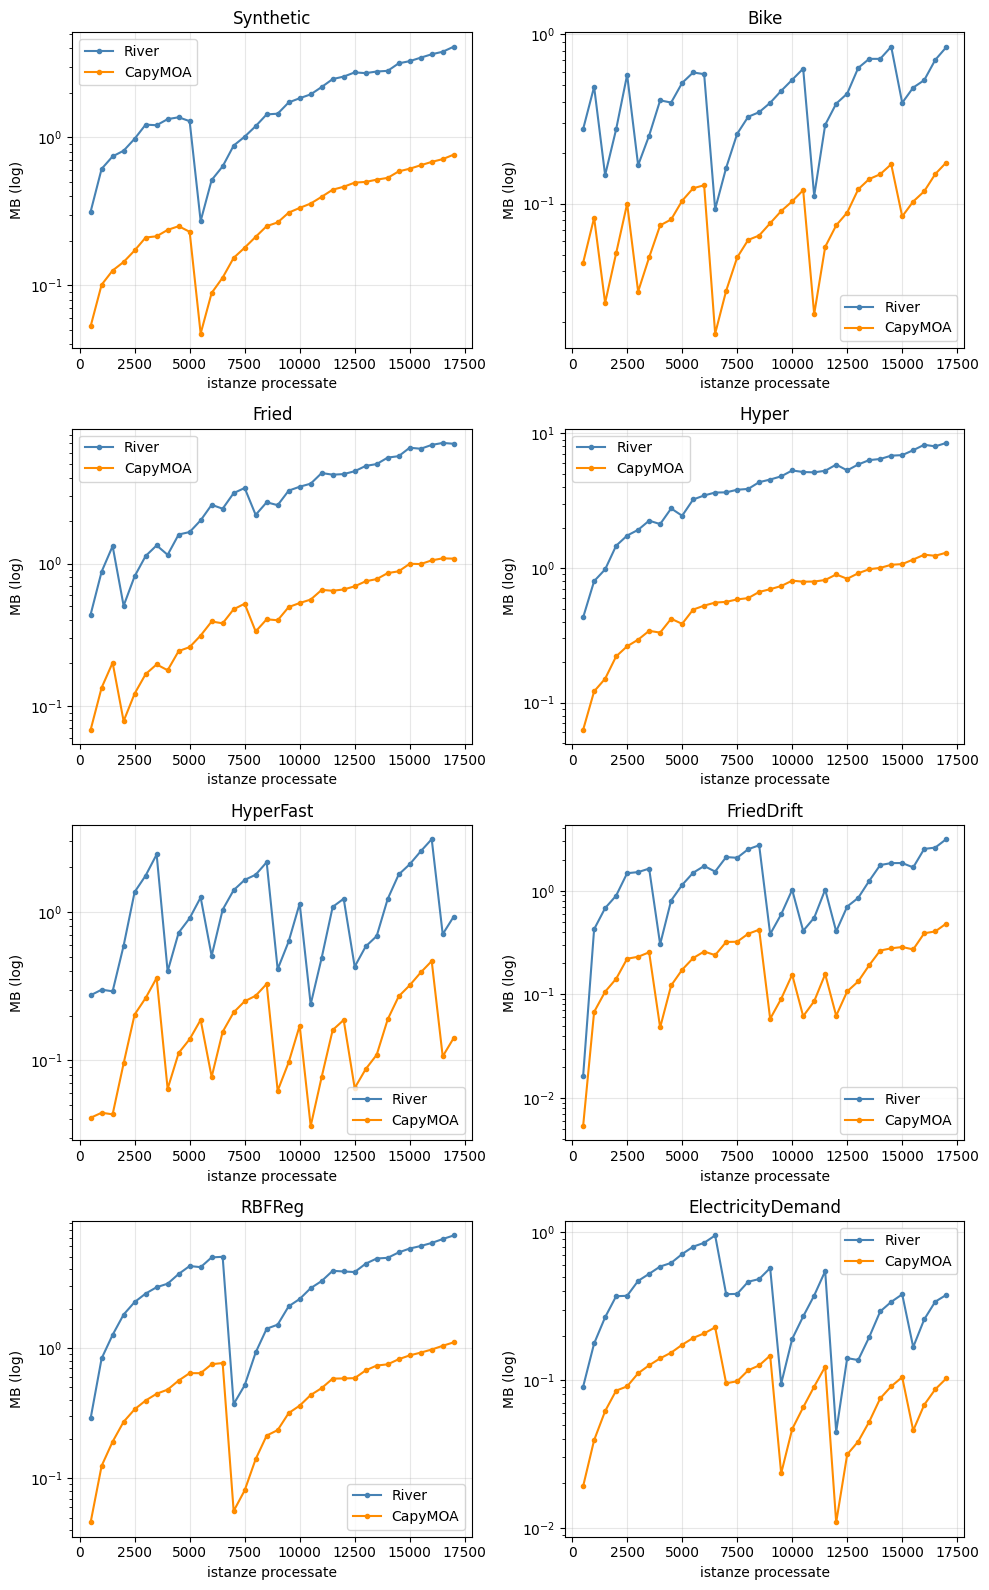

In [14]:
cfg = CONFIGS["deterministic (mean, no-bootstrap)"]
traces = {}
for ds_name, (X, y, schema) in datasets.items():
    _, _, _, _, tr_r = utils.prequential_eval(X, y, 'river', cfg, BASE, scale=SCALE, sample_every=SAMPLE_EVERY)
    _, _, _, _, tr_c = utils.prequential_eval(X, y, 'capy', cfg, BASE, schema=schema, scale=SCALE, sample_every=SAMPLE_EVERY)
    traces[ds_name] = {"River": tr_r, "CapyMOA": tr_c}
    print(f"{ds_name}: River {tr_r[-1]['model_MB']:.3f} MB | CapyMOA {tr_c[-1]['model_MB']:.4f} MB")

colors  = {"River": "steelblue", "CapyMOA": "darkorange"}
ds_list = list(datasets.keys())

ncols = 2
nrows = -(-len(ds_list) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(10, 4 * nrows))
axes = axes.flatten()
for ax, ds_name in zip(axes, ds_list):
    for fw in ("River", "CapyMOA"):
        t  = traces[ds_name][fw]
        ns = [p["n"]        for p in t]
        vs = [p["model_MB"] for p in t]
        ax.plot(ns, vs, label=fw, color=colors[fw], marker="o", markersize=3)
    ax.set_yscale("log")
    ax.set_title(ds_name)
    ax.set_xlabel("istanze processate")
    ax.set_ylabel("MB (log)")
    ax.legend(); ax.grid(alpha=0.3)

for ax in axes[len(ds_list):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()